<a href="https://colab.research.google.com/github/ArthY07/Projet-Graphes-Et-Reseaux-L3/blob/main/Feschet_Arthur_Chayrigues_Noah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install osmnx
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import random
import time



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.7 MB/s eta 0:00:00


In [ ]:
# Projet Graphes et Réseaux
## Question 1
##On modèlise le problème à l'aide d'un graphe orienté valué G=(V,E) ou V est l'ensemble des adresses
##On considère aussi que E est l'ensemble des arêtes, ici des routes.
##On ajoute un arc de longueur d(i,j) de i vers j, s'il existe une route entre i et j. L'objectif est de trouver l'itinéraire le plus rapide entre
##le sommet de départ ((i) entrepôt) et une adresse (j) revient à trouver le plus court chemin entre i et j dans G.


In [ ]:
# Question 2
def find_min(N,pi):

  minimum= 999999999
  for x in N :
      if pi[x] < minimum:
          minimum=pi[x]
          resultat = x

  return resultat

def dijkstra_optimise(G, source, target):
    p = source
    parent = {}
    pi = {}
    noeuds_a_initialiser = list(G.nodes())
    i = 0
    while i < len(noeuds_a_initialiser):
        noeud_actuel = noeuds_a_initialiser[i]
        pi[noeud_actuel] = 9999999
        i += 1

    pi[source] = 0
    Q = [source]

    while Q:
        p = find_min(Q, pi)
        if p == target:
            break
        Q.remove(p)

        neighbors = [key for key in G[p]]
        for x in neighbors:
            # On adapte juste ces deux lignes aux données de la carte
            poids = G[p][x][0].get("travel_time", 1)

            if pi[x] > pi[p] + poids:
                pi[x] = pi[p] + poids
                parent[x] = p
                Q.append(x)

    chemin = [target]
    actuel = target
    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()
    return chemin, pi[target]

Lancement du benchmark...
Taille 100 terminée.
Taille 300 terminée.
Taille 500 terminée.
Taille 800 terminée.
Taille 1000 terminée.


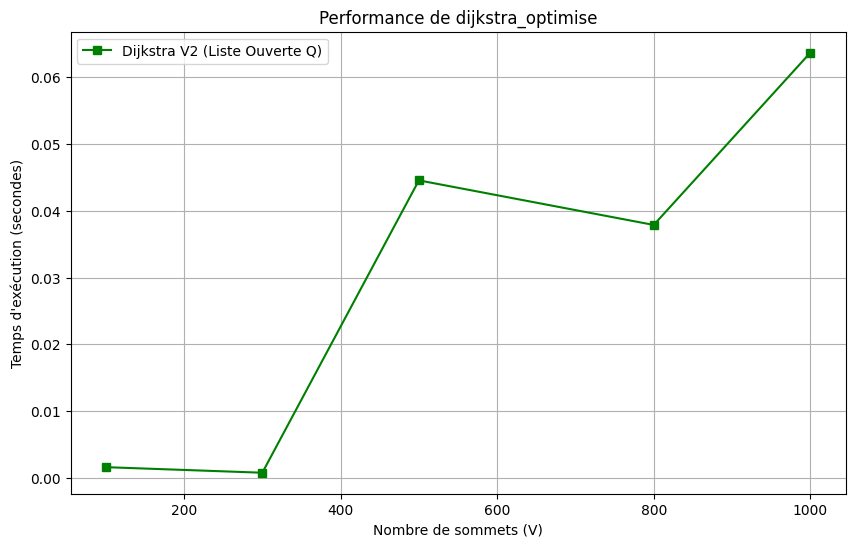

In [ ]:
sizes = [100, 300, 500, 800, 1000]
times_optimise = []

print("Lancement du benchmark...")

for n in sizes:
    G = nx.gnm_random_graph(n, n * 5, directed=False)
    G = nx.MultiGraph(G)

    # 1. Boucle pour ajouter les poids sur toutes les arêtes
    for u, v, data in G.edges(data=True):
        data['travel_time'] = random.randint(1, 10)

    # 2. En dehors de la boucle des arêtes, on prépare les paramètres
    source = 0
    target = n - 1

    # 3. Lancement du chronomètre et exécution d'un SEUL test par taille de graphe
    start = time.time()

    # Assure-toi que ta fonction dijkstra_optimise est bien définie plus haut dans ton script
    dijkstra_optimise(G, source, target)

    times_optimise.append(time.time() - start)
    print(f"Taille {n} terminée.")

# 4. En dehors de la grande boucle 'for n in sizes', on affiche le résultat global
plt.figure(figsize=(10, 6))
plt.plot(sizes, times_optimise, label='Dijkstra V2 (Liste Ouverte Q)', marker='s', color='green')
plt.title("Performance de dijkstra_optimise")
plt.xlabel("Nombre de sommets (V)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True)
plt.show()

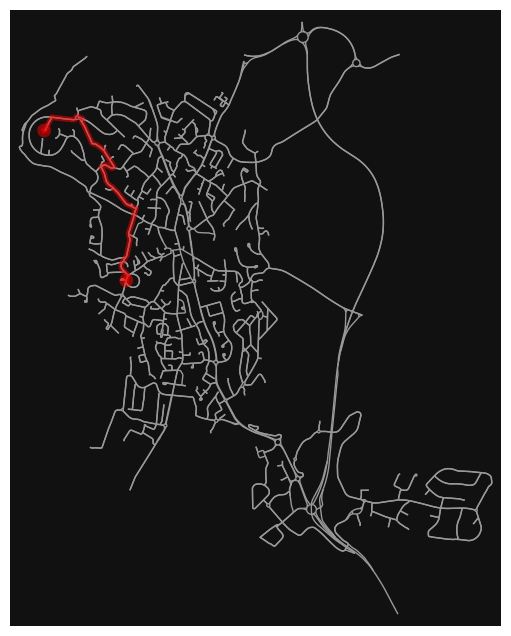

Temps de trajet estimé : 2.963606444275403 minutes
Temps de trajet estimé arrondi: 3.0 minutes


In [ ]:
# Question 4
location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}
G = ox.graph_from_place("Saint-Gély-du-Fesc, France", network_type="drive")
G = ox.add_edge_speeds(G) # Ajoutez cette ligne pour calculer les vitesses
G = ox.add_edge_travel_times(G)


for u, v, key, data in G.edges(keys=True, data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

chemin, duree = dijkstra_optimise(G, Entrepôt, Client)

fig, ax = ox.plot_graph_route(G, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de trajet estimé : {duree / 60} minutes")
print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")


## Partie 2 Projet

In [ ]:
# # Projet Graphes et Réseaux
# # Question 1, nous allons essayer de faire Paul Valéry amphi 7 à Villeneuve les Maguelone
#Nous décidons de ne pas éxecuter le code car cela prend trop de temps. Cependant l'explication ci dessous permet de comprendre :

# location = {
#     "0": (43.633951, 3.869172),  # Amphi 7
#     "1": (43.544559, 3.846384)   # Villeneuve
# }
# G = ox.graph_from_place(["Hérault, France"], network_type="drive")
# G = ox.add_edge_speeds(G)
# G = ox.add_edge_travel_times(G)

# for u, v, key, data in G.edges(keys=True, data=True):
#     if 'travel_time' in data:
#         data['weight'] = data['travel_time']

# Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
# Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

# chemin, duree = dijkstra_optimise(G, Entrepôt, Client)

# fig, ax = ox.plot_graph_route(G, chemin, route_color='red', route_linewidth=4, node_size=0)
# print(f"Temps de trajet estimé : {duree / 60} minutes")
# print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")





# Explication Question 1 Partie 2

Le constat est que Dijkstra est un algorithme « aveugle » : il n'a aucune notion de direction. Il explore tous les sommets de proche en proche à partir de notre point de départ. De ce fait il "s'étale" en explorant tous ses sommets, c'est-à-dire qu'il avance de manière circulaire tout autour de notre point de départ. Il va vérifier à chaque fois chaque sommet le plus proche donc il tourne et s'élargit au fur et à mesure.

C'est pourquoi dans un graphe plus dense il y a plus d'intersections et plus de noeud. L'algorithme de Dijkstra va donc vérifier chaque voisin, même ceux qui partent complètement à l'opposé de la destination parce qu'ils sont proches du départ. Tant qu'un chemin vers le Sud est plus court que le début du trajet vers le Nord (où se trouve notre arrivée), il continuera d'explorer dans la mauvaise direction. Il teste donc chaque rue adjacente même si elle s'éloigne de notre arrivée. C'est ce qui explique pourquoi il traite autant de nœuds inutiles par rapport à A* qui, lui possède une intuition du chemin pour accéder à l'arrivé grâce à l'heuristique.

In [ ]:
#A étoile Algo
# Question 2
import math

location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}

def Heuristique(G, source, target):
  x1 = G.nodes[source]['x']
  y1 = G.nodes[source]['y']
  x2 = G.nodes[target]['x']
  y2 = G.nodes[target]['y']
  distance = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5
  return distance

def find_min_A(G, target, N, pi):
    minimum = 999999999
    noeud = N[0]

    for x in N:
        score = pi[x] + Heuristique(G, x, target)
        if score < minimum:
            minimum = score
            noeud = x

    return noeud


def A_Etoile(G, source, target):
    p = source
    parent = {}
    pi = {}
    noeuds_a_initialiser = list(G.nodes())
    i = 0
    while i < len(noeuds_a_initialiser):
        noeud_actuel = noeuds_a_initialiser[i]
        pi[noeud_actuel] = 9999999
        i += 1

    pi[source] = 0
    Q = [source]

    while Q:
        p = find_min_A(G,target,Q,pi)
        if p == target:
          break
        Q.remove(p)

        for x in G.neighbors(p):
            # On adapte juste ces deux lignes aux données de la carte
            poids = G[p][x][0].get("travel_time", 1)

            if pi[x] > pi[p] + poids:
                pi[x] = pi[p] + poids
                parent[x] = p
                if x not in Q:
                  Q.append(x)

    chemin = [target]
    actuel = target
    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()
    return chemin, pi[target]

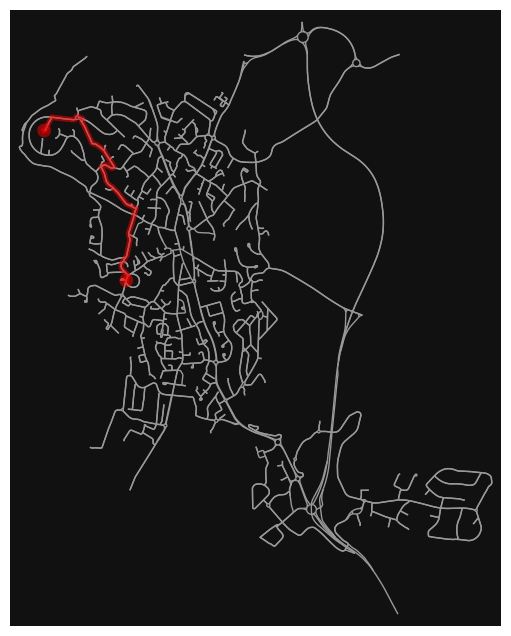

Temps de trajet estimé : 2.963606444275403 minutes
Temps de trajet estimé arrondi: 3.0 minutes


In [ ]:
# Affichage A Etoile
location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}
G = ox.graph_from_place("Saint-Gély-du-Fesc, France", network_type="drive")
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)


for u, v, key, data in G.edges(keys=True, data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

chemin, duree = A_Etoile(G, Entrepôt, Client)

fig, ax = ox.plot_graph_route(G, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de trajet estimé : {duree / 60} minutes")
print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")
print()

On a récupéré 50 paires
Exemple (Départ, Arrivée) : [(6780485335, 726810320), (1871512185, 234469527), (333643709, 297060296)]


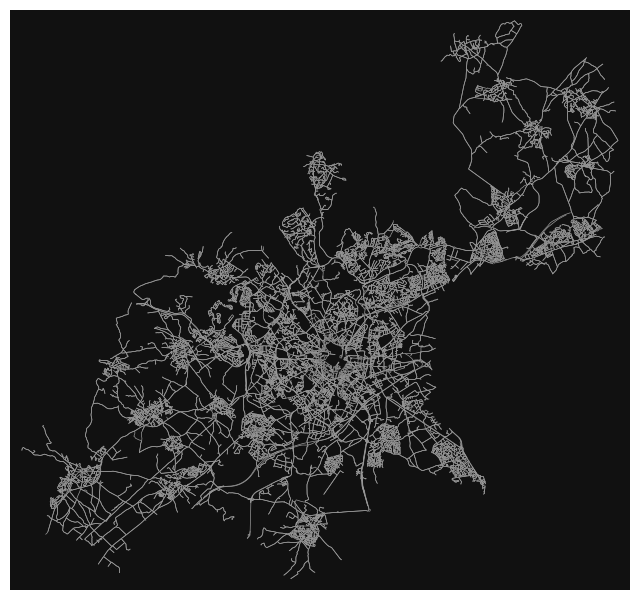

Lancement du benchmark...


In [ ]:
 ## Question 3

G = ox.graph_from_place(["Montpellier Méditerranée Métropole, France"], network_type="drive")
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

nodes = list(G.nodes())
paires = []

# Tirage aléatoire 50 paires de nœuds (départ/arrivée)
for i in range(50):
    depart, arrivee = random.sample(nodes, 2)
    paires.append((depart, arrivee))

print(f"On a récupéré 50 paires")
print("Exemple (Départ, Arrivée) :", paires[:3])

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

times_dijkstra = []
times_astar = []

print("Lancement du benchmark...")

for depart, arrivee in paires:
    start_d = time.time()
    dijkstra_optimise(G, depart, arrivee)
    times_dijkstra.append(time.time() - start_d)

    start_a = time.time()
    A_Etoile(G, depart, arrivee)
    times_astar.append(time.time() - start_a)

print("Benchmark terminé")

# Affichage graphique
plt.figure(figsize=(10, 6))
plt.boxplot([times_dijkstra, times_astar], tick_labels=['Dijkstra', 'A_Etoile'])
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Comparaison sur 50 paires réelles, Métropole Montpellier")
plt.grid(True)
plt.show()